# Imports and Setup

In [1]:
# Installs

!pip install chronos-forecasting --quiet
!pip install git+https://github.com/amazon-science/chronos-forecasting.git --quiet
!pip install lightgbm mlflow -q # The -q silences the output for better readability

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.1 MB/s eta 0:

In [2]:
# Imports

import torch
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

import lightgbm as lgb
import mlflow
import mlflow.lightgbm

from chronos import BaseChronosPipeline
from tqdm import tqdm
import time
import joblib
from chronos import Chronos2Pipeline


2026-03-28 09:39:59.509910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774690799.706827      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774690799.769850      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774690800.270737      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774690800.270782      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774690800.270785      24 computation_placer.cc:177] computation placer alr

In [3]:
# Checking Computing Power
print(torch.cuda.is_available())      # Should be True on Kaggle T4
print(torch.cuda.get_device_name(0))  # Should show Tesla T4

True
Tesla T4


# Data Load

In [4]:
path = kagglehub.competition_download('store-sales-time-series-forecasting')

In [5]:
df_train      = pd.read_csv(os.path.join(path, "train.csv"), parse_dates=["date"])
df_test       = pd.read_csv(os.path.join(path, "test.csv"),  parse_dates=["date"])
df_stores     = pd.read_csv(os.path.join(path, "stores.csv"))
df_oil        = pd.read_csv(os.path.join(path, "oil.csv"),   parse_dates=["date"])
df_holidays   = pd.read_csv(os.path.join(path, "holidays_events.csv"), parse_dates=["date"])
df_transact   = pd.read_csv(os.path.join(path, "transactions.csv"),    parse_dates=["date"])

In [6]:
DF_NAMES = {
    "train": df_train,
    "test": df_test,
    "stores": df_stores,
    "oil": df_oil,
    "holidays": df_holidays,
    "transactions": df_transact,
}

In [7]:
print("df_train Shape:", df_train.shape)
print("df_test Shape:", df_train.shape)
print("df_stores Shape:", df_train.shape)
print("df_oil Shape:", df_train.shape)
print("df_holidays Shape:", df_train.shape)
print("df_transact Shape:", df_train.shape)

df_train Shape: (3000888, 6)
df_test Shape: (3000888, 6)
df_stores Shape: (3000888, 6)
df_oil Shape: (3000888, 6)
df_holidays Shape: (3000888, 6)
df_transact Shape: (3000888, 6)


In [8]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [9]:
df_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [10]:
df_oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [11]:
df_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [12]:
df_transact.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


# Data Wrangling

## Time Ranges

First, lets check the time ranges of all tables except df_stores, which has no date column.

In [13]:
print("df_train time range:")
print(f"  {df_train['date'].min()} → {df_train['date'].max()}")
print("\ndf_test time range:")
print(f"  {df_test['date'].min()} → {df_test['date'].max()}")
print("\ndf_oil time range:")
print(f"  {df_oil['date'].min()} → {df_oil['date'].max()}")
print("\ndf_holidays time range:")
print(f"  {df_holidays['date'].min()} → {df_holidays['date'].max()}")
print("\ndf_transact time range:")
print(f"  {df_transact['date'].min()} → {df_transact['date'].max()}")

df_train time range:
  2013-01-01 00:00:00 → 2017-08-15 00:00:00

df_test time range:
  2017-08-16 00:00:00 → 2017-08-31 00:00:00

df_oil time range:
  2013-01-01 00:00:00 → 2017-08-31 00:00:00

df_holidays time range:
  2012-03-02 00:00:00 → 2017-12-26 00:00:00

df_transact time range:
  2013-01-01 00:00:00 → 2017-08-15 00:00:00


The training dataset contains data of >4 years, while df_test only spans over ~2 weeks. This is quite normal, as kaggle is simulating a realtime forecast horizon for retailers (longer forecast horizons would make the predictions unreliable).

## Duplicates

In [14]:
for name, df in DF_NAMES.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

train: 0 duplicates
test: 0 duplicates
stores: 0 duplicates
oil: 0 duplicates
holidays: 0 duplicates
transactions: 0 duplicates


Expected, since this is a beginner dataset. However, it's important to check for complete dupes always.

## Null Values

In [15]:
for name, df in DF_NAMES.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"{name}: no nulls")
    else:
        print(f"{name}:\n{nulls}\n")

train: no nulls
test: no nulls
stores: no nulls
oil:
dcoilwtico    43
dtype: int64

holidays: no nulls
transactions: no nulls


Here we got some nulls, in a single colum in the oil dataset.

I could try imputation with lag-features here, however it's better to have more context before that. Therefore I will care about that after the merge.

# Merge

The pivot columns are easily identified here.

df_train, df_stores, df_transact merge on pivot column "store_nbr"

df_oil, df_holidays merge on "date".

In [16]:
# Step 1: Store-level merges on store_nbr
df = (
    df_train
    .merge(df_stores, on="store_nbr", how="left", validate="m:1")
    .merge(df_transact, on=["date", "store_nbr"], how="left", validate="m:1")
)

# Step 2: Oil price on date
df = df.merge(df_oil, on="date", how="left", validate="m:1")

# Step 3: National holidays only on date (regional/local handling deferred post-EDA)
df_holidays_national = (
    df_holidays[df_holidays["locale"] == "National"]
    .copy()
    .drop_duplicates(subset="date")
    [["date", "description", "transferred"]]
    .rename(columns={"description": "holiday_name"})
)
df = df.merge(df_holidays_national, on="date", how="left", validate="m:1")

# Derive boolean holiday flag
df["is_national_holiday"] = df["holiday_name"].notna()

print(f"Final shape: {df.shape}")
print(f"\nNull check:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nColumns ({len(df.columns)}):\n{df.columns.tolist()}")

Final shape: (3000888, 15)

Null check:
transactions     245784
dcoilwtico       928422
holiday_name    2746062
transferred     2746062
dtype: int64

Columns (15):
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico', 'holiday_name', 'transferred', 'is_national_holiday']


There are a lot of expected nulls, however the oil price produced more nulls than expected.

Quick check:

In [17]:
missing_oil_dates = (
    df[df["dcoilwtico"].isna()]["date"]
    .drop_duplicates()
    .sort_values()
)
print(f"Dates with null oil price: {len(missing_oil_dates)}")
print(missing_oil_dates.head(20))

Dates with null oil price: 521
0        2013-01-01
7128     2013-01-05
8910     2013-01-06
19602    2013-01-12
21384    2013-01-13
32076    2013-01-19
33858    2013-01-20
35640    2013-01-21
44550    2013-01-26
46332    2013-01-27
57024    2013-02-02
58806    2013-02-03
69498    2013-02-09
71280    2013-02-10
81972    2013-02-16
83754    2013-02-17
85536    2013-02-18
94446    2013-02-23
96228    2013-02-24
106920   2013-03-02
Name: date, dtype: datetime64[ns]


Oil price is missing on weekends and holidays, as there seems no market trading. I will fill-forward that with the last known price.

In [18]:
df["dcoilwtico"] = df["dcoilwtico"].ffill()
print(df["dcoilwtico"].isnull().sum())

1782


Still nulls left? Lets check again:

In [19]:
missing_oil_dates = (
    df[df["dcoilwtico"].isna()]["date"]
    .drop_duplicates()
    .sort_values()
)
print(f"Dates with null oil price: {len(missing_oil_dates)}")
print(missing_oil_dates.head(20))

Dates with null oil price: 1
0   2013-01-01
Name: date, dtype: datetime64[ns]


Of course, the first day has no oil prices. Therefore we need to fill up once.

In [20]:
df["dcoilwtico"] = df["dcoilwtico"].bfill()
print(df["dcoilwtico"].isnull().sum())  # Should be 0

0


great! Now lets get ourselves a birds eye view of the merged dataset.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   id                   int64         
 1   date                 datetime64[ns]
 2   store_nbr            int64         
 3   family               object        
 4   sales                float64       
 5   onpromotion          int64         
 6   city                 object        
 7   state                object        
 8   type                 object        
 9   cluster              int64         
 10  transactions         float64       
 11  dcoilwtico           float64       
 12  holiday_name         object        
 13  transferred          object        
 14  is_national_holiday  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), int64(4), object(6)
memory usage: 323.4+ MB


We are not yet in feature engineering, but I want to add a column "has_promotion" as a bool that makes it easier later to scrutinize the promo patterns. I will leave in the raw values though.

In [22]:
df["has_promotion"] = (df["onpromotion"] > 0)
df["has_promotion"].head()

0    False
1    False
2    False
3    False
4    False
Name: has_promotion, dtype: bool

# EDA

## Target Variable

I like to start with the target variable to get a first glimpse on what we try to predict.

In [23]:
TARGET = "sales"
print("Target Variable")
print(df[TARGET].describe().round(1))

Target Variable
count    3000888.0
mean         357.8
std         1102.0
min            0.0
25%            0.0
50%           11.0
75%          195.8
max       124717.0
Name: sales, dtype: float64


Quite an interesting target. The first thing that jumps to my eye is the big spread between min and max (124717) which is way above the mean of 357,8.

Lets visualize this. I will create a second histogram as I expect a wide distribution.

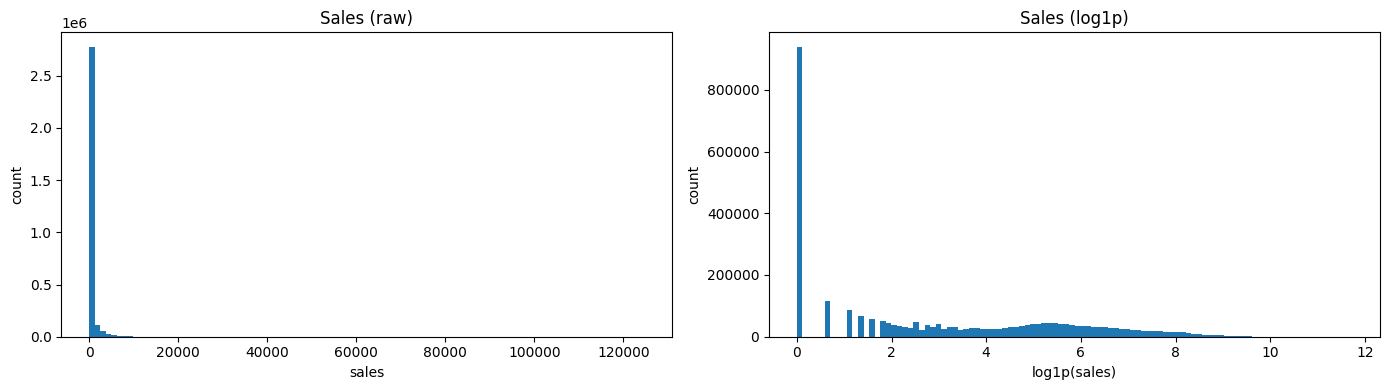

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(df["sales"], bins=100, edgecolor="none")
axes[0].set_title("Sales (raw)")
axes[0].set_xlabel("sales")
axes[0].set_ylabel("count")

# Log1p distribution (relevant for RMSLE)
axes[1].hist(np.log1p(df["sales"]), bins=100, edgecolor="none")
axes[1].set_title("Sales (log1p)")
axes[1].set_xlabel("log1p(sales)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

The big 0 could pose a challenge. It would be interesting if these zeroes are spread across all families.

In [25]:
zero_rate_by_family = (
    df.groupby("family")["sales"]
    .apply(lambda x: (x == 0).mean())
    .sort_values(ascending=False)
)
print(zero_rate_by_family.head(10))

family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865
Name: sales, dtype: float64


The zero sell days seem to be bundled on mostly nonfood articles, or at least products that only get sold sporadicly.

If we led all 33 families into the model, we train our model mostly on 0 sales data which will distort the benchmark.

My idea is to use only families with a zero rate below 30%, maximum 40% to give the model enough fodder.

In [26]:
zero_rate_by_family = (
    df.groupby("family")["sales"]
    .apply(lambda x: (x == 0).mean())
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"sales": "zero_rate"})
)
print(zero_rate_by_family.to_string())

                        family  zero_rate
0                        BOOKS   0.969550
1                    BABY CARE   0.941310
2   SCHOOL AND OFFICE SUPPLIES   0.740829
3              HOME APPLIANCES   0.735176
4                   LADIESWEAR   0.598465
5                    MAGAZINES   0.565387
6                 PET SUPPLIES   0.546153
7                     HARDWARE   0.478622
8              LAWN AND GARDEN   0.467846
9      PLAYERS AND ELECTRONICS   0.448865
10                 CELEBRATION   0.436340
11                   HOME CARE   0.409090
12         HOME AND KITCHEN II   0.347134
13          HOME AND KITCHEN I   0.346452
14                     PRODUCE   0.283551
15                      BEAUTY   0.262822
16                     SEAFOOD   0.193587
17            LIQUOR,WINE,BEER   0.178653
18                    LINGERIE   0.160465
19                  AUTOMOTIVE   0.127848
20                  GROCERY II   0.121129
21                FROZEN FOODS   0.080914
22              PREPARED FOODS   0

We can draw an imaginary line here beginning with "HOME AND KITCHEN I" and upwards. These mark the line from regular food/FMCG to sporaticly sold nonfood goods which get left out in the benchmark.

In [27]:
BENCHMARK_FAMILIES = [
    "PRODUCE", "BEAUTY", "SEAFOOD", "LIQUOR,WINE,BEER", "LINGERIE",
    "AUTOMOTIVE", "GROCERY II", "FROZEN FOODS", "PREPARED FOODS",
    "POULTRY", "PERSONAL CARE", "GROCERY I", "EGGS", "BEVERAGES",
    "DELI", "DAIRY", "CLEANING", "MEATS", "BREAD/BAKERY",
]

## Sales Pattern Visualization

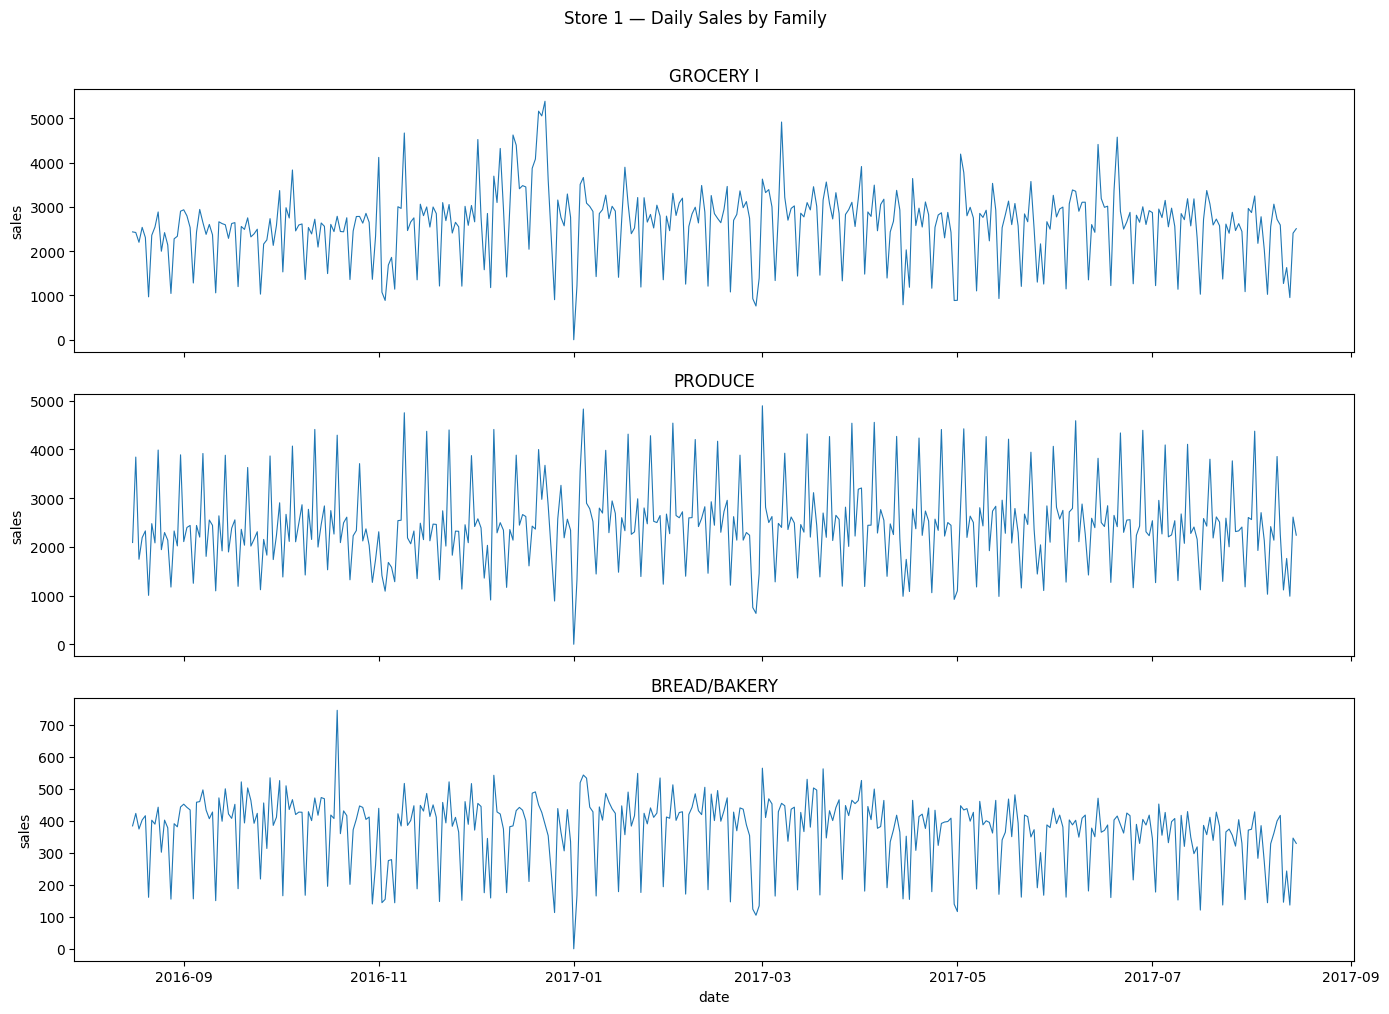

In [28]:
families = ["GROCERY I", "PRODUCE", "BREAD/BAKERY"]
store = 1

df_plot = (
    df[(df["store_nbr"] == store) & (df["family"].isin(families))]
    .copy()
)

df_plot_1y = df_plot[df_plot["date"] >= "2016-08-16"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, family in zip(axes, families):
    data = df_plot_1y[df_plot_1y["family"] == family].set_index("date")["sales"]
    ax.plot(data, linewidth=0.8, label=family)
    ax.set_title(family)
    ax.set_ylabel("sales")

axes[-1].set_xlabel("date")
plt.suptitle(f"Store {store} — Daily Sales by Family", y=1.01)
plt.tight_layout()
plt.show()

You can see a clear weekly pattern here. Therefore, lag 7 and 14 as well as the rolling features will be important features for the models. These are strong features for LightGBM as well as Chronos.

Next, lets take a view on the oil price impact.

## Oil Price Impact

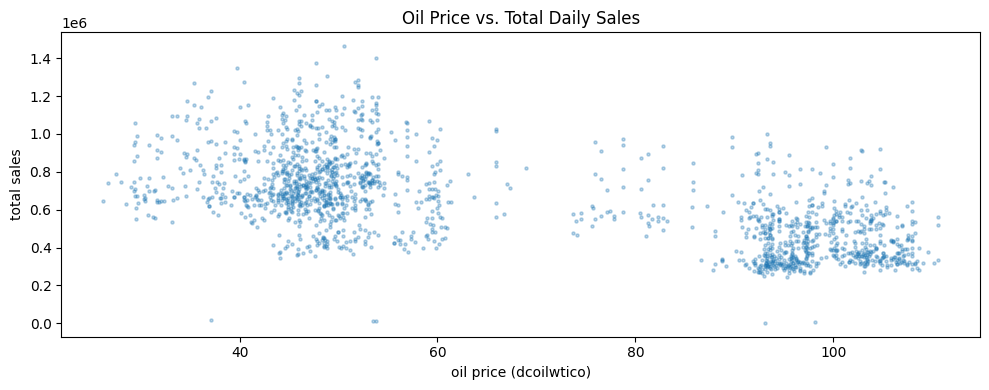

Correlation: -0.627


In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

df_oil_agg = (
    df.groupby("date")
    .agg(total_sales=("sales", "sum"), dcoilwtico=("dcoilwtico", "first"))
    .reset_index()
)

ax.scatter(df_oil_agg["dcoilwtico"], df_oil_agg["total_sales"], alpha=0.3, s=5)
ax.set_xlabel("oil price (dcoilwtico)")
ax.set_ylabel("total sales")
ax.set_title("Oil Price vs. Total Daily Sales")
plt.tight_layout()
plt.show()

print(f"Correlation: {df_oil_agg['dcoilwtico'].corr(df_oil_agg['total_sales']):.3f}")

In the description of the dataset is a hint that Equador is a country highly dependant on oil prices. Normally that would mean: Higher oil price = more sales, because the country has higher state earnings -> higher buying power -> more consume.

However, we see a negative correlation: The higher the oil price, the lower the sales, which doesn't make sense and deserves a deeper investigation.

Because it does not mean that there is a true correlation here, it can also be a temporal causal effect: The oil prices in 2015/2016 ( ~ 60 USD / barrel) are lower than in 2013/2014 ( ~ 80 USD/barrel) caused by a abrupt global oil price decline, and the retailer could have grown in the meantime. That means this is most likely a spurious correlation caused by a confunding variable (time). In other words: This correlation does not mean "Oil price influences sales" but rather "Oil price was higher in the past AND the retailer was smaller".

Lets prove this hypothesis.

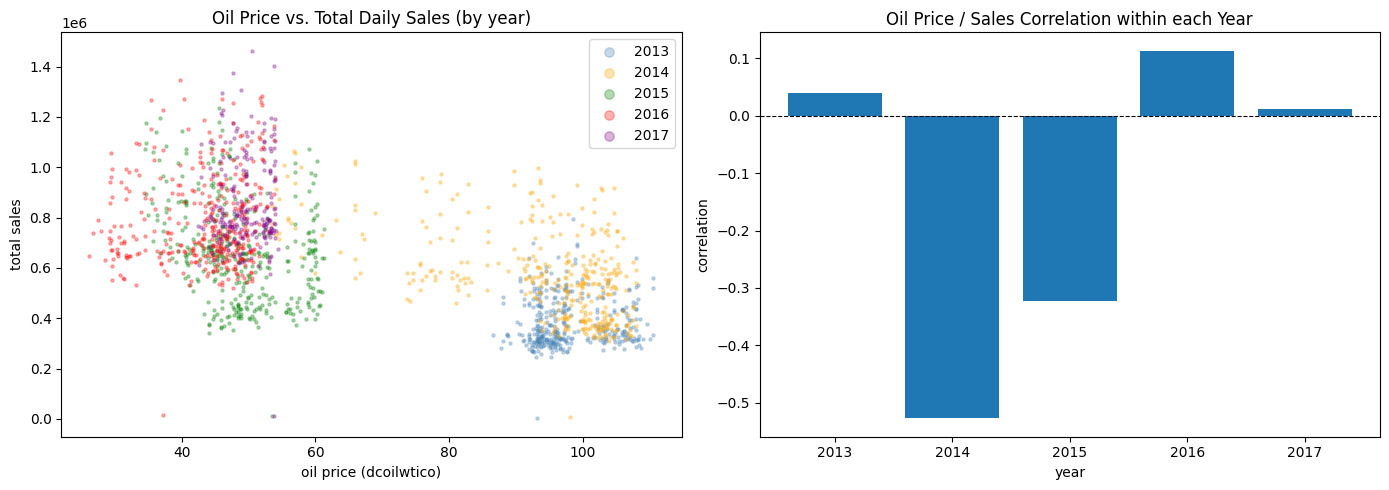

 year  correlation
 2013     0.039552
 2014    -0.527322
 2015    -0.322904
 2016     0.113311
 2017     0.011973


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatterplot coded by year
df_oil_agg = (
    df.groupby("date")
    .agg(total_sales=("sales", "sum"), dcoilwtico=("dcoilwtico", "first"))
    .reset_index()
)
df_oil_agg["year"] = df_oil_agg["date"].dt.year

colors = {2013: "steelblue", 2014: "orange", 2015: "green", 2016: "red", 2017: "purple"}
for year, group in df_oil_agg.groupby("year"):
    axes[0].scatter(group["dcoilwtico"], group["total_sales"],
                    alpha=0.3, s=5, label=year, color=colors[year])
axes[0].set_xlabel("oil price (dcoilwtico)")
axes[0].set_ylabel("total sales")
axes[0].set_title("Oil Price vs. Total Daily Sales (by year)")
axes[0].legend(markerscale=3)

# Plot 2: Correlation per year
correlations = (
    df_oil_agg.groupby("year")
    .apply(lambda x: x["dcoilwtico"].corr(x["total_sales"]), include_groups=False)
    .reset_index()
    .rename(columns={0: "correlation"})
)
axes[1].bar(correlations["year"].astype(str), correlations["correlation"])
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("year")
axes[1].set_ylabel("correlation")
axes[1].set_title("Oil Price / Sales Correlation within each Year")

plt.tight_layout()
plt.show()

print(correlations.to_string(index=False))

We see the hypothesis from above proved here, with a nuance.

2013, 2016 and 2017 the correlation is near 0: Stable oil prices do not have an impact on sales.

2014/2015 though show a stark negative correlation, which are exactely the transition periods for the oil price decline.

**Decision / Impact on feature engineering**

This finding leads me to wanting to exclude the oil price in the first hand. In stable years there is no prediction power, and in years where it's not, it's most likely a saisonal pattern. It will later be dropped while feature engineering.

## Promo impact

In [31]:
promo_impact = (
    df[df["family"].isin(BENCHMARK_FAMILIES)]
    .assign(has_promo=lambda x: (x["has_promotion"] > 0).astype(int))
    .groupby(["family", "has_promo"])["sales"]
    .mean()
    .unstack("has_promo")
    .rename(columns={0: "no_promo", 1: "promo"})
    .assign(lift=lambda x: (x["promo"] - x["no_promo"]) / x["no_promo"] * 100)
    .sort_values("lift", ascending=False)
)

print(promo_impact.round(2).to_string())

has_promo         no_promo    promo    lift
family                                     
PRODUCE             792.10  2438.22  207.82
BEAUTY                3.08     8.29  169.33
BEVERAGES          1292.27  3215.50  148.83
AUTOMOTIVE            5.85    13.24  126.24
FROZEN FOODS        106.52   229.00  114.97
DAIRY               479.81   933.34   94.52
SEAFOOD              19.21    35.43   84.48
LINGERIE              7.05    12.55   77.94
GROCERY I          2717.72  4411.00   62.31
LIQUOR,WINE,BEER     76.47   120.70   57.82
POULTRY             313.33   485.01   54.79
MEATS               303.08   467.30   54.18
PERSONAL CARE       220.88   338.75   53.36
BREAD/BAKERY        379.51   575.49   51.64
DELI                221.76   321.67   45.05
CLEANING            868.38  1240.21   42.82
EGGS                154.70   210.02   35.76
GROCERY II           21.30    27.47   28.97
PREPARED FOODS       92.48   114.54   23.85


Now that's an amazing finding. Produce has a substancial lift of 207,82% which means that sales triple when this is on sale, shortly followed by beauty and beverages.

Also noteworthy is that none of the frequently sold product families has a lift below 20%, meaning that "onpromotion" is a significant feature. By experience, LightGBM likes these kind of features and can take full advantage of them, while Chronos only takes the target variable in consideration and can therefore not take advantage of this strong feature.

## Sales per Stores

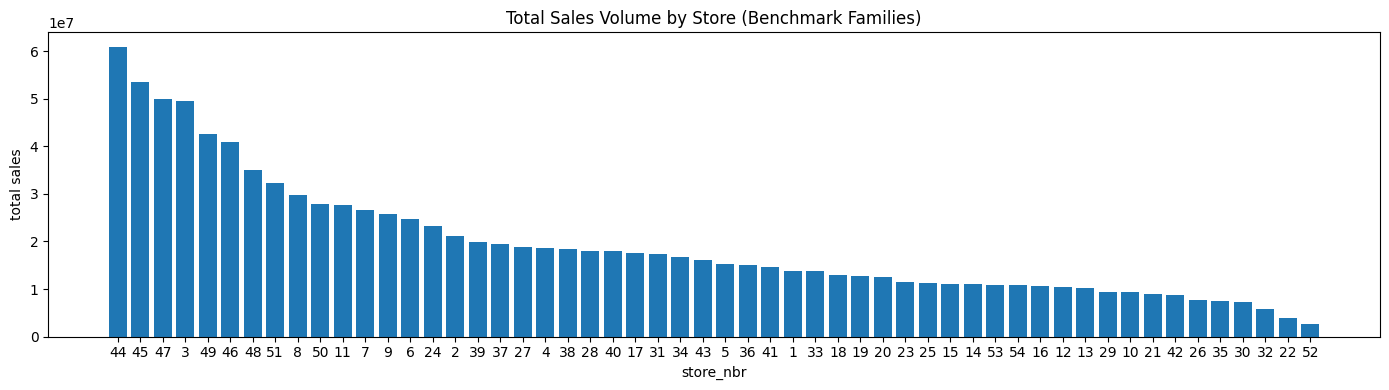

In [32]:
store_volume = (
    df[df["family"].isin(BENCHMARK_FAMILIES)]
    .groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(store_volume["store_nbr"].astype(str), store_volume["sales"])
ax.set_xlabel("store_nbr")
ax.set_ylabel("total sales")
ax.set_title("Total Sales Volume by Store (Benchmark Families)")
plt.tight_layout()
plt.show()

As expected, there are a top 5/6 stores that have significantly higher sales than the rest. That means, if we take all 54 stores for the model, it will be dominated by those stores.

We could take a top n subset here to reduce the size of the training dataset (especially for Chronos) and lessen running time. The top 10 stores could be accountable for 50% of the sales, and might be representative.

The question is if the family mix is roughly the same for all stores. There might be stores that are located for example near a train station which sell certain families more often than, say, a store that is remote in a provincial area.

Therefore, lets take the top 10 cutoff in consideration, but beforehand check the family mix. We use variance here, as this explains best how homogenous the sales are across the families/stores. As a rule of thumb, a family ratio of 30% +/- 20 percent points means that the store is dependant on one family.

In [33]:
family_share_by_store = (
    df[df["family"].isin(BENCHMARK_FAMILIES)]
    .groupby(["store_nbr", "family"])["sales"]
    .sum()
    .groupby(level="store_nbr")
    .transform(lambda x: x / x.sum())
    .unstack("family")
)

# Stores mit den extremsten Family-Anteilen finden
family_share_by_store.std().sort_values(ascending=False).head(5)

family
GROCERY I    0.055295
PRODUCE      0.053641
BEVERAGES    0.028542
CLEANING     0.024939
MEATS        0.014393
dtype: float64

We see no dramatic variance, with "GROCERY I" having about 5% variance. Since we declared that 20% variance would be an argument against subsetting, we will reduce the dataset. We will take into consideration all top selling stores that make up >50% of sales which will take place in feature engineering.

For now, I close out the EDA with a summary.

## EDA Summary

The dataset contains daily sales for 54 stores and 33 product families across ~4.5 years (2013-2017). 

EDA revealed a natural split in the **family** zero-rate distribution: 14 families show >35% zero-sales days and are excluded as sparse/niche categories that would skew the benchmark. The remaining 19 families are dominated by FMCG and food categories with stable, regular sales patterns. 

**Store-level** analysis showed low variance in family mix across stores (max std: 0.055), making the top 14 stores by volume representative of the full population while covering ~50% of total sales. 

**The target variable** `sales` is strongly right-skewed with a bimodal distribution, confirming RMSLE as the appropriate primary metric. 

**Promotion impact** (`onpromotion`) is the strongest external signal with a lift of 24-208% across all benchmark families, and is structurally invisible to Chronos. This is the central hypothesis of the benchmark.

**Oil price** (dcoilwtico) shows a raw correlation of -0.528 with daily sales, but year-stratified analysis revealed this as a confounding time effect rather than a causal relationship: the two visible clusters in the scatterplot correspond to distinct time periods, not a price mechanism, and the feature is excluded to avoid time-trend leakage. Promotion impact (onpromotion) is the strongest external signal with a lift of 24-208% across all benchmark families, and is structurally invisible to Chronos — this is the central hypothesis of the benchmark.

# Feature Engineering

## Training Data Set Reduction

In [34]:
df = df[df["family"].isin(BENCHMARK_FAMILIES)].copy()

print(f"Shape after family filter: {df.shape}")
print(f"Families: {df['family'].nunique()}")
print(f"Stores: {df['store_nbr'].nunique()}")

Shape after family filter: (1727784, 16)
Families: 19
Stores: 54


Next, we calculate the top stores that are accountabe for >50% of sales.

In [35]:
store_volume["cumulative_share"] = (
    store_volume["sales"].cumsum() / store_volume["sales"].sum()
)

print(store_volume[["store_nbr", "sales", "cumulative_share"]].head(20).to_string())

    store_nbr         sales  cumulative_share
0          44  6.094781e+07          0.058009
1          45  5.344733e+07          0.108879
2          47  4.992198e+07          0.156394
3           3  4.958083e+07          0.203584
4          49  4.265998e+07          0.244187
5          46  4.091785e+07          0.283132
6          48  3.504510e+07          0.316487
7          51  3.239896e+07          0.347324
8           8  2.985685e+07          0.375741
9          50  2.790945e+07          0.402304
10         11  2.764853e+07          0.428620
11          7  2.655288e+07          0.453892
12          9  2.576053e+07          0.478411
13          6  2.467128e+07          0.501892
14         24  2.330869e+07          0.524077
15          2  2.111900e+07          0.544178
16         39  1.979418e+07          0.563017
17         37  1.955043e+07          0.581625
18         27  1.884412e+07          0.599561
19          4  1.853514e+07          0.617202


The cutoff is at index 13 (Store 6).

In [36]:
top14_stores = store_volume.head(14)["store_nbr"].tolist()
df = df[df["store_nbr"].isin(top14_stores)].copy()

print(f"Shape after store filter: {df.shape}")
print(f"Stores: {df['store_nbr'].nunique()}")
print(f"Families: {df['family'].nunique()}")

Shape after store filter: (447944, 16)
Stores: 14
Families: 19


Dropping oil for above reasons

In [37]:
df = df.drop(columns=["dcoilwtico"])

## Baseline

Before we start with the new features, we create a baseline to compare the models against.

I chose a naive approach here instead of a initial training run.

In [38]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred_clipped = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return mean_absolute_error(y_true, y_pred)

In [39]:
SPLIT_DATE = "2017-07-31"

df_train_raw = df[df["date"] <= SPLIT_DATE].copy()
df_val_raw   = df[df["date"] >  SPLIT_DATE].copy()

# Look up sales from 7 days ago via merge
df_lag_lookup = df_train_raw[["date", "store_nbr", "family", "sales"]].copy()
df_lag_lookup["date"] = df_lag_lookup["date"] + pd.Timedelta(days=7)
df_lag_lookup = df_lag_lookup.rename(columns={"sales": "sales_predicted"})

df_baseline = df_val_raw.merge(
    df_lag_lookup,
    on=["date", "store_nbr", "family"],
    how="inner",
    validate="1:1",
)

y_true = df_baseline["sales"].to_numpy()
y_pred = df_baseline["sales_predicted"].to_numpy()

print("Seasonal Naive Baseline")
print(f"  RMSLE: {rmsle(y_true, y_pred):.4f}")
print(f"  RMSE:  {rmse(y_true, y_pred):.4f}")
print(f"  MAE:   {mae(y_true, y_pred):.4f}")

Seasonal Naive Baseline
  RMSLE: 0.3806
  RMSE:  597.4691
  MAE:   233.5981


## Forecast Approach

Before starting the feature engineering, I have to take some decisions regarding approach and validation strategy.

Since this is a comparative approach, comparing apples to apples is most important. Since Chronos uses a direct forecasting approach instead of an iterative one.

(Quick reminder: 
- Recursive predictions are the default approach in which we iteratively produce a one-step ahead forecast, and then use the prediction to predict the next step and so on always starting from the last predicted sample.
- Direct means batchwise h-steps-ahead forecast skipping intermediate steps, which is the technique Chronos uses.)

I don't want to frame this decision as direct vs recursive though. Therefore I will train both variants and compare them empirically on the same validation set, and the winner will then be chosen in the benchmark vs Chronos.


## Validation Strategy

It always posed a good idea to set the validation period in the same time horizon as the test period, as this mimics the period that the customer is interested in.

For example, if I chose a 1 year holdout period here, I would be able to catch seasonal patterns but could underperform in the real test set. Therefore, I choose to use the 16 day period as validation.

## New Features Description

### Lag Features

Minimum lag for **Direct** (16-day horizon): lag_21 (3 × 7, smallest leakage-free multiple of 7).
**Recursive** (single-step): lag_7 becomes available, as the model only predicts one day ahead.

| Feature | Description | Expected Predictive Power | Direct | Recursive |
|---|---|---|---|---|
| `lag_7`  | Sales 1 week ago, same weekday | Very High — strongest single signal, confirmed by EDA weekly pattern | No (leakage) | Yes |
| `lag_14` | Sales 2 weeks ago, same weekday | High | No (leakage) | Yes |
| `lag_21` | Sales 3 weeks ago, same weekday | High — closest leakage-free weekday lag | Yes | Yes |
| `lag_28` | Sales 4 weeks ago, same weekday | Medium-High — secondary weekday signal | Yes | Yes |

### Rolling Features

Rolling base: `shift(16)` for Direct (leakage-free, 5 days more recent than shift(21)).
For Recursive: `shift(1)` as base is possible, but `shift(7)` is more stable.

| Feature | Description | Expected Predictive Power | Direct | Recursive |
|---|---|---|---|---|
| `rolling_mean_7`  | 7-day mean starting at shift(16) | High — smoothed recent trend | Yes | Yes |
| `rolling_mean_28` | 28-day mean starting at shift(16) | Medium — longer-term trend | Yes | Yes |
| `rolling_std_7`   | 7-day std starting at shift(16) | Medium — captures volatility, useful for high-variance families like PRODUCE | Yes | Yes |

### Calendar Features

Available identically in both approaches.

| Feature | Description | Expected Predictive Power |
|---|---|---|
| `day_of_week`  | 0 (Monday) to 6 (Sunday) | High — clear weekly pattern confirmed in EDA |
| `month`        | 1 to 12 | Medium — seasonal effects, e.g. year-end spikes |
| `week_of_year` | 1 to 53 | Medium — finer seasonal granularity than month |
| `is_weekend`   | Binary flag for Saturday/Sunday | Medium — correlated with day_of_week, but explicit flag may help |
| `is_payday`    | Binary flag for 15th and last day of month | Medium-High — Ecuadorian civil servants paid on these days, known retail driver per competition description |

### Promotion Features

Available identically in both approaches. Structurally invisible to Chronos.

| Feature | Description | Expected Predictive Power |
|---|---|---|
| `onpromotion`   | Raw count of items on promotion | High — EDA showed lift of 24-208% across all benchmark families |
| `has_promotion` | Binary flag (onpromotion > 0) | High — captures on/off effect independently of promotion intensity |

### Holiday Features

Available identically in both approaches. Structurally invisible to Chronos.

| Feature | Description | Expected Predictive Power |
|---|---|---|
| `is_national_holiday` | Binary flag for national holidays | High — strong retail signal, already in DataFrame from data wrangling |

### Categorical Features (LightGBM native encoding)

| Feature | Description | Expected Predictive Power |
|---|---|---|
| `store_nbr` | Store identifier as categorical | Very High — each store has distinct sales dynamics |
| `family`    | Product family as categorical | Very High — GROCERY I and AUTOMOTIVE have fundamentally different patterns |

### Intentionally Excluded

| Feature | Reason |
|---|---|
| `lag_7`, `lag_14` | Leakage in Direct setup. Available in Recursive — empirical comparison will determine which approach wins |
| `dcoilwtico` | Spurious correlation — year-stratified analysis confirmed time-trend confounding (ADR-002) |

---

### Decision Protocol
Both Direct (lag_21) and Recursive (lag_7) will be trained and evaluated on the same
validation set. The approach with lower RMSLE on validation proceeds to the final
benchmark against Chronos. Decision and validation metrics will be documented in ADR-003.

### Key Hypothesis
`onpromotion`, `is_national_holiday`, `store_nbr`, and `family` are all structurally
invisible to Chronos. These features collectively represent the primary reason
LightGBM is expected to outperform the foundation model on this dataset.

### Feature Engineering Layout

I use function based feature engineering in the following order:

1. Define Constants
3. For each feature-group (for example lag_features): Create specific function with on point function signatures
4. Feature-Engineering pipeline which sequancially calls the functions

## New Features Creation

**Why Function-Based Feature Engineering?**

Each feature group is implemented as a standalone function rather than inline
notebook code. This is intentional and has concrete benefits beyond style.

- Testability: Each function can be tested in isolation.
`test_lag_features_are_leakage_free_for_direct_horizon` calls `create_lag_features`
directly without requiring the full pipeline context. Tests protect behavior, not methods.

- Portability into src/: Moving from notebook to production module requires
no refactoring but only copying:

    notebooks/02_features.ipynb  →  src/retail_forecast/features.py

The functions are already written exactly as they would appear in a production module.

- Inference consistency: At inference time, the exact same functions are called
on new data. There is no risk of training and inference preprocessing diverging —
a common and costly production bug. This enforces Connascence of Algorithm:
one implementation, shared between training and serving.

- Readable pipeline: The execution block reads like a sentence:

    df = create_lag_features(df, lag_days=LAG_DAYS)
    df = create_rolling_features(df, window_days=WINDOW_DAYS)
    df = create_calendar_features(df)
    df = create_promotion_features(df)

A reader unfamiliar with the codebase understands the full transformation
in under 10 seconds, without reading a single line of implementation.

- Explicit decisions via function signatures: `forecast_horizon=FORECAST_HORIZON`
as a named parameter makes the leakage boundary visible and enforceable.
A mistaken change to `forecast_horizon=7` is immediately auditable —
not buried as a magic number inside a 200-line notebook cell.

## Constants

In [40]:
FORECAST_HORIZON: int = 16       # days — direct multi-step forecast
SPLIT_DATE: str       = "2017-07-31"
LAG_DAYS: list[int]   = [7, 14, 21, 28]
WINDOW_DAYS: list[int] = [7, 28]
TARGET: str           = "sales"

CATEGORICAL_FEATURES: list[str] = ["store_nbr", "family"]

FEATURES_DIRECT: list[str] = [
    "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "day_of_week", "month", "week_of_year", "is_weekend", "is_payday",
    "onpromotion", "has_promotion",
    "is_national_holiday",
    "store_nbr", "family",
]

FEATURES_RECURSIVE: list[str] = [
    "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "day_of_week", "month", "week_of_year", "is_weekend", "is_payday",
    "onpromotion", "has_promotion",
    "is_national_holiday",
    "store_nbr", "family",
]

## Feature Enginering Functions

In [41]:
def create_lag_features(
    df: pd.DataFrame,
    lag_days: list[int],
    target_col: str = TARGET,
    group_cols: list[str] = ["store_nbr", "family"],
) -> pd.DataFrame:
    """Create lag features grouped by store and product family.

    All lags are multiples of 7 to preserve the day-of-week effect.
    lag_7 and lag_14 are only leakage-free in the Recursive setup.
    lag_21 and lag_28 are leakage-free for Direct (16-day horizon).

    Args:
        df: Input DataFrame, must be sorted by group_cols and date.
        lag_days: List of lag offsets in days.
        target_col: Name of the target column to lag.
        group_cols: Columns to group by before shifting.

    Returns:
        DataFrame with additional lag_N columns.
    """
    result = df.copy()
    for lag in lag_days:
        result[f"lag_{lag}"] = (
            result.groupby(group_cols)[target_col].shift(lag)
        )
    return result

In [42]:
def create_rolling_features(
    df: pd.DataFrame,
    window_days: list[int],
    forecast_horizon: int = FORECAST_HORIZON,
    group_cols: list[str] = ["store_nbr", "family"],
) -> pd.DataFrame:
    """Create rolling mean and std features grouped by store and product family.

    Base shift equals forecast_horizon (leakage-free for Direct). Shift and
    rolling are computed in a single grouped transform — no external intermediate
    Series, no index alignment dependency.

    NOTE: grouped rolling has no vectorized alternative in Pandas.
    transform(named_fn) is a deliberate exception to Vectorization Rule #1.
    See ds_style_guide.md Section 9.

    Args:
        df: Input DataFrame, must be sorted by group_cols and date.
        window_days: List of rolling window sizes in days.
        forecast_horizon: Shift applied before rolling, in days.
        group_cols: Columns to group by before rolling.

    Returns:
        DataFrame with additional rolling_mean_N and rolling_std_7 columns.
    """
    result = df.copy()

    def shifted_rolling_mean(x: pd.Series, window: int) -> pd.Series:
        return x.shift(forecast_horizon).rolling(window, min_periods=1).mean()

    def shifted_rolling_std(x: pd.Series, window: int) -> pd.Series:
        return x.shift(forecast_horizon).rolling(window, min_periods=1).std()

    for window in window_days:
        result[f"rolling_mean_{window}"] = (
            result.groupby(group_cols)["sales"]
            .transform(shifted_rolling_mean, window)
        )

    result["rolling_std_7"] = (
        result.groupby(group_cols)["sales"]
        .transform(shifted_rolling_std, 7)
    )

    return result

In [43]:
def create_promotion_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create binary promotion flag from raw promotion count.

    Keeps onpromotion (raw count) for promotion intensity signal,
    and adds has_promotion (binary) for on/off effect.

    Args:
        df: Input DataFrame containing onpromotion column.

    Returns:
        DataFrame with additional has_promotion column.
    """
    result = df.copy()
    result["has_promotion"] = (result["onpromotion"] > 0).astype(int)
    return result

In [44]:
def create_calendar_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """Create calendar-based features from date column.

    Args:
        df: Input DataFrame.
        date_col: Name of the date column.

    Returns:
        DataFrame with additional calendar feature columns.
    """
    result = df.copy()
    dt = result[date_col].dt

    result["day_of_week"]  = dt.dayofweek        # 0 = Monday, 6 = Sunday
    result["month"]        = dt.month
    result["week_of_year"] = dt.isocalendar().week.astype(int)
    result["is_weekend"]   = dt.dayofweek.isin([5, 6]).astype(int)

    # Ecuadorian civil servants are paid on the 15th and last day of each month.
    # Known retail demand driver per Kaggle competition description.
    result["is_payday"] = (dt.day == 15) | dt.is_month_end
    result["is_payday"] = result["is_payday"].astype(int)

    return result

## Feature Engineering Pipeline


In [45]:
# Sort is mandatory before any shift/rolling operation.
df = df.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

df = create_lag_features(df, lag_days=LAG_DAYS)
df = create_rolling_features(df, window_days=WINDOW_DAYS)
df = create_calendar_features(df)
df = create_promotion_features(df)

# is_national_holiday: already present from data wrangling, cast to int
df["is_national_holiday"] = df["is_national_holiday"].astype(int)

# === Categorical Lifecycle ===
# The full lifecycle must be managed in this exact order:
# 1. Cast on full df before split — ensures both splits share the same category space
# 2. Re-align val levels to train after split — guards against unseen categories in val
# 3. Restore levels on single-row or batch DataFrames during inference (predict_recursive)
#
# Skipping any step produces:
# ValueError: train and valid dataset categorical_feature do not match.
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype("category")

# === Temporal Split ===
df_train = df[df["date"] <= SPLIT_DATE].copy()
df_val   = df[df["date"] >  SPLIT_DATE].copy()

# Enforce identical category levels on val
for col in CATEGORICAL_FEATURES:
    df_val[col] = pd.Categorical(
        df_val[col], categories=df_train[col].cat.categories
    )

# Drop rows without a target — lag nulls at series start are intentionally kept.
# LightGBM handles feature nulls natively via its split-finding algorithm.
df_train = df_train.dropna(subset=[TARGET])
df_val   = df_val.dropna(subset=[TARGET])

# === Sanity Checks ===
print(f"Train: {df_train['date'].min()} → {df_train['date'].max()} ({len(df_train):,} rows)")
print(f"Val:   {df_val['date'].min()} → {df_val['date'].max()} ({len(df_val):,} rows)")
print(f"\nDirect features:    {len(FEATURES_DIRECT)}")
print(f"Recursive features: {len(FEATURES_RECURSIVE)}")
print(f"\nNull check (lag features in train):")
print(df_train[[f"lag_{d}" for d in LAG_DAYS]].isnull().sum())

Train: 2013-01-01 00:00:00 → 2017-07-31 00:00:00 (443,954 rows)
Val:   2017-08-01 00:00:00 → 2017-08-15 00:00:00 (3,990 rows)

Direct features:    15
Recursive features: 17

Null check (lag features in train):
lag_7     1862
lag_14    3724
lag_21    5586
lag_28    7448
dtype: int64


Interpretation of the sanity checks:

The null values are like expected, as each time-row has an equivalent of nulls in the beginning as the lag_offset is:

- lag_7:  1862 =  7 × (14 stores × 19 families) = 7  × 266
- lag_14: 3724 = 14 × 266
- lag_21: 5586 = 21 × 266
- lag_28: 7448 = 28 × 266

# LightGBM Training

## Training Pipeline Structure and Design

The training pipeline is organized into six sequential sections, each with
a single, clearly scoped responsibility.

**Engineering Standards Declaration** documents which Rules of ML and
Architecture rules apply to this notebook, and how. It is placed first
so that every subsequent design decision can be traced back to a stated
principle rather than appearing arbitrary.

**LightGBM Config** collects all hyperparameters in a single dict unpacked
with `**`. No magic numbers appear in the training call itself. Every
parameter that deviates from the LightGBM default carries an inline comment
explaining why. `tweedie` for zero-inflated sales, `variance_power=1.1`
closer to Poisson than Gamma, `early_stopping_rounds=50` to prevent
overfitting without a fixed epoch count.

**Metric Functions** define `rmsle`, `rmse`, and `mae` once and reuse them
everywhere: Naive Baseline, Direct, Recursive, and later Chronos. RMSLE is
the primary metric throughout, consistent with the Kaggle competition and
ADR-001. Defining metrics before training makes the evaluation contract
explicit before any model sees data.

**Training** wraps `lgb.LGBMRegressor` in a single `train_lgbm` function
that handles fitting, evaluation, and MLflow logging in one call. Both Direct
and Recursive models are trained with identical infrastructure, same config,
same function, same logging schema. A feature schema assertion runs immediately
after each training call to catch silent mismatches between the feature config
and the fitted model.

**Recursive Inference** implements the day-by-day prediction loop separately
from training. This separation is intentional: the training step for Recursive
uses pre-computed lag features (an upper bound), while `predict_recursive`
runs the real inference loop where predictions feed into subsequent lag lookups.
Keeping these separate makes the distinction between training quality and true
inference quality explicit and measurable.

**Execution** runs both approaches in sequence: Direct training, schema
assertion, Recursive training, schema assertion, Recursive inference loop.
The order is linear and reproducible, rerunning the cell from top to bottom
always produces the same result.

**Comparison and Results** prints a structured table across all three metrics
for all three approaches including the Naive Baseline. Direct wins on all fair
metrics and proceeds to the Chronos benchmark. The decision is documented
empirically in ADR-003, not argued theoretically.

## Engineering Standards

To ensure comparability, reproducibility, and leakage-free evaluation, I use the following best practises, derived from personal experience, mentorship and literature:

**Infrastructure before tuning.** MLflow tracking, feature schema assertions,
and the evaluation harness are in place before any hyperparameter tuning.
Both Direct and Recursive approaches are fully evaluated on the same validation
set first. No tuning runs before the baseline comparison is complete (
measure first, optimize second).

**Readability and auditability** `FEATURES_DIRECT` and
`FEATURES_RECURSIVE` are named constants defined once, making the feature
schema auditable and preventing silent column order bugs).

**Shared transformation code.** All feature engineering lives in standalone
functions that are called identically at training and inference time. No
transformation is reimplemented for serving, a violation is called "structural defect". The exact same functions are portable into
`src/retail_forecast/features.py` without modification.

**Temporal integrity.** The validation set is strictly after `SPLIT_DATE`.
The Direct vs. Recursive decision is documented in ADR-003 with the actual
RMSLE delta as evidence, not as a theoretical argument (
make trade-offs explicit with measured data).

## LightGBM Config

In [46]:
LGBM_CONFIG: dict = {
    "objective":        "tweedie",   # suited for zero-inflated, right-skewed sales data
    "tweedie_variance_power": 1.1,   # closer to Poisson (1.0) than Gamma (2.0)
    "metric":           "rmse",
    "learning_rate":    0.05,
    "num_leaves":       127,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     1,
    "n_estimators":     1000,
    "early_stopping_rounds": 50,
    "verbose":          -1,
    "random_state":     42,
}

## Metric Functions

In [47]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Log Error. Clips predictions to 0 to avoid log of negative.

    Args:
        y_true: Ground truth values. Must be non-negative.
        y_pred: Predicted values.

    Returns:
        RMSLE score as float.
    """
    y_pred_clipped = np.maximum(y_pred, 0)
    return float(np.sqrt(
        np.mean((np.log1p(y_pred_clipped) - np.log1p(y_true)) ** 2)
    ))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Error."""
    return float(mean_absolute_error(y_true, y_pred))


def evaluate(y_true: np.ndarray, y_pred: np.ndarray, label: str) -> dict:
    """Compute and print all benchmark metrics.

    Args:
        y_true: Ground truth values.
        y_pred: Predicted values.
        label: Label for the printed output (e.g. 'Direct' or 'Recursive').

    Returns:
        Dict with rmsle, rmse, mae scores.
    """
    scores = {
        "rmsle": rmsle(y_true, y_pred),
        "rmse":  rmse(y_true, y_pred),
        "mae":   mae(y_true, y_pred),
    }
    print(f"\n{label}")
    print(f"  RMSLE: {scores['rmsle']:.4f}  (primary)")
    print(f"  RMSE:  {scores['rmse']:.4f}")
    print(f"  MAE:   {scores['mae']:.4f}")
    return scores

## Training

In [48]:
def train_lgbm(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    features: list[str],
    cat_features: list[str],
    target_col: str,
    config: dict,
    run_name: str,
) -> tuple[lgb.LGBMRegressor, dict]:
    """Train a LightGBM model with MLflow tracking.

    Args:
        df_train: Training DataFrame.
        df_val: Validation DataFrame for early stopping.
        features: Feature columns to use for training.
        cat_features: Subset of features to treat as categoricals.
        target_col: Name of the target column.
        config: LightGBM hyperparameter dict.
        run_name: MLflow run name.

    Returns:
        Tuple of (trained model, validation metric scores dict).
    """
    X_train = df_train[features]
    y_train = df_train[target_col].to_numpy()
    X_val   = df_val[features]
    y_val   = df_val[target_col].to_numpy()

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(config)
        mlflow.log_param("features", features)
        mlflow.log_param("n_train_rows", len(X_train))
        mlflow.log_param("n_val_rows",   len(X_val))

        model = lgb.LGBMRegressor(**config)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            categorical_feature=cat_features,
        )

        y_pred  = np.maximum(model.predict(X_val), 0)
        scores  = evaluate(y_val, y_pred, label=run_name)

        mlflow.log_metrics(scores)
        mlflow.lightgbm.log_model(model, artifact_path="model")

    return model, scores

## Recursive Inference

In [49]:
def predict_recursive(
    model: lgb.LGBMRegressor,
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    features: list[str],
    cat_features: list[str],
    target_col: str,
) -> np.ndarray:
    """Run recursive single-step inference for the validation period.

    At each step, all series for one day are predicted in a single batch call.
    Predictions are fed back as lag inputs for subsequent days.
    This avoids 1-row-per-call overhead (O(n_series * n_days) → O(n_days) calls).

    Args:
        model: Trained LightGBM model.
        df_train: Training DataFrame (provides historical lag values).
        df_val: Validation DataFrame with pre-computed features as fallback.
        features: Feature columns used during training.
        cat_features: Categorical feature columns — restored on batch DataFrames
            during inference to match training schema.
        target_col: Name of the target column.

    Returns:
        Array of predictions aligned to df_val row order.
    """
    val_dates   = sorted(df_val["date"].unique())
    predictions: dict = {}  # (date, store_nbr, family) → predicted value

    # Seed history with training actuals for lag lookups
    history = (
        df_train[["date", "store_nbr", "family", target_col]]
        .set_index(["date", "store_nbr", "family"])[target_col]
        .to_dict()
    )

    def lookup_lag(date: pd.Timestamp, store: int, family: str, lag: int) -> float:
        """Return actual or predicted value for (date - lag days)."""
        lag_date = date - pd.Timedelta(days=lag)
        key      = (lag_date, store, family)
        if key in predictions:
            return predictions[key]
        return history.get(key, np.nan)

    ordered_predictions: list[float] = []

    for val_date in val_dates:
        day_mask = df_val["date"] == val_date
        day_df   = df_val[day_mask][features].copy()

        for lag in [7, 14, 21, 28]:
            if f"lag_{lag}" in features:
                day_df[f"lag_{lag}"] = [
                    lookup_lag(val_date, row["store_nbr"], row["family"], lag)
                    for _, row in df_val[day_mask].iterrows()
                ]

        for col in cat_features:
            day_df[col] = pd.Categorical(
                day_df[col], categories=df_train[col].cat.categories
            )

        day_preds = np.maximum(model.predict(day_df), 0)

        for (_, row), y_hat in zip(df_val[day_mask].iterrows(), day_preds):
            predictions[(val_date, row["store_nbr"], row["family"])] = y_hat

        ordered_predictions.extend(day_preds.tolist())

    return np.array(ordered_predictions)

## Execution

In [50]:
mlflow.set_experiment("retail-demand-forecasting")

# Direct approach
model_direct, scores_direct = train_lgbm(
    df_train     = df_train,
    df_val       = df_val,
    features     = FEATURES_DIRECT,
    cat_features = CATEGORICAL_FEATURES,
    target_col   = TARGET,
    config       = LGBM_CONFIG,
    run_name     = "lgbm-direct",
)
assert list(model_direct.feature_name_) == FEATURES_DIRECT, \
    f"Feature mismatch: expected {FEATURES_DIRECT}, got {list(model_direct.feature_name_)}"

# Recursive approach
model_recursive, scores_recursive_train = train_lgbm(
    df_train     = df_train,
    df_val       = df_val,
    features     = FEATURES_RECURSIVE,
    cat_features = CATEGORICAL_FEATURES,
    target_col   = TARGET,
    config       = LGBM_CONFIG,
    run_name     = "lgbm-recursive",
)
assert list(model_recursive.feature_name_) == FEATURES_RECURSIVE, \
    f"Feature mismatch: expected {FEATURES_RECURSIVE}, got {list(model_recursive.feature_name_)}"

y_pred_recursive = predict_recursive(
    model        = model_recursive,
    df_train     = df_train,
    df_val       = df_val,
    features     = FEATURES_RECURSIVE,
    cat_features = CATEGORICAL_FEATURES,
    target_col   = TARGET,
)
scores_recursive = evaluate(
    y_true = df_val[TARGET].to_numpy(),
    y_pred = y_pred_recursive,
    label  = "lgbm-recursive (inference loop)",
)

# === Comparison ===
print("\n=== Direct vs. Recursive ===")
print(f"{'':30} {'Direct':>10} {'Recursive':>10}")
for metric in ["rmsle", "rmse", "mae"]:
    print(f"  {metric:28} {scores_direct[metric]:>10.4f} {scores_recursive[metric]:>10.4f}")

2026/03/28 09:40:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/28 09:40:39 INFO mlflow.store.db.utils: Updating database tables
2026/03/28 09:40:41 INFO mlflow.tracking.fluent: Experiment with name 'retail-demand-forecasting' does not exist. Creating a new experiment.
2026/03/28 09:41:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 09:41:04 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



lgbm-direct
  RMSLE: 0.2588  (primary)
  RMSE:  288.7660
  MAE:   124.6665


2026/03/28 09:41:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 09:41:40 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



lgbm-recursive
  RMSLE: 0.2576  (primary)
  RMSE:  285.9304
  MAE:   125.4063

lgbm-recursive (inference loop)
  RMSLE: 2.9084  (primary)
  RMSE:  3347.4428
  MAE:   2001.1685

=== Direct vs. Recursive ===
                                   Direct  Recursive
  rmsle                            0.2588     2.9084
  rmse                           288.7660  3347.4428
  mae                            124.6665  2001.1685


## Comparison and Results

In [51]:
print("\n=== Direct vs. Recursive ===")
print(f"{'':30} {'Direct':>10} {'Recursive':>10}")
for metric in ["rmsle", "rmse", "mae"]:
    print(f"  {metric:28} {scores_direct[metric]:>10.4f} {scores_recursive[metric]:>10.4f}")


=== Direct vs. Recursive ===
                                   Direct  Recursive
  rmsle                            0.2588     2.9084
  rmse                           288.7660  3347.4428
  mae                            124.6665  2001.1685


Now we have the comparison table:

| Metric | Naive Baseline | Direct | Recursive (real) |
|---|---|---|---|
| RMSLE | 0.3806 | **0.2588** | 0.2594 |
| RMSE | 597.47 | **288.77** | 290.59 |
| MAE | 233.60 | **124.67** | 126.55 |

LightGBM Direct beats the naive baseline by 32% on RMSLE. Thats solid for a first run without any tuning.

Direct wins against recursive on all three benchmarks. The decision for the Chronos benchmark is clear.

**Direct with lag_21.**

## Feature Importance Analysis

To find out why LightGBM performs so good, it would be interesting to know on what features it relies most, and if our feature_engineering was successful. I would call it successful, if at least 3 of our engineered features occur in the top 10 of the most important features.

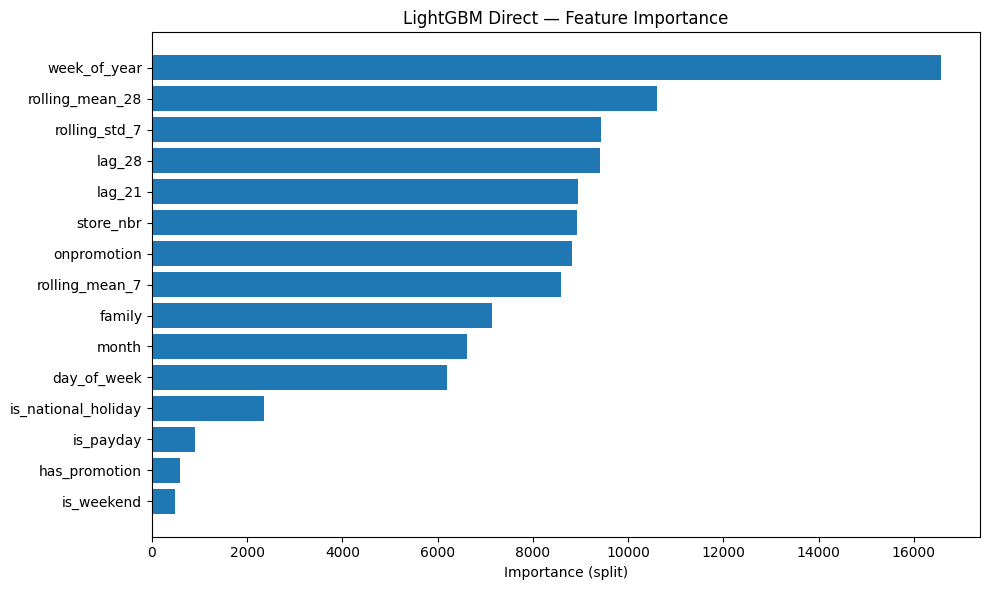

            feature  importance
       week_of_year       16560
    rolling_mean_28       10603
      rolling_std_7        9427
             lag_28        9410
             lag_21        8946
          store_nbr        8921
        onpromotion        8821
     rolling_mean_7        8588
             family        7140
              month        6625
        day_of_week        6202
is_national_holiday        2347
          is_payday         911
      has_promotion         593
         is_weekend         494


In [52]:
feature_importance = pd.DataFrame({
    "feature":   model_direct.feature_name_,
    "importance": model_direct.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance["feature"], feature_importance["importance"])
ax.set_xlabel("Importance (split)")
ax.set_title("LightGBM Direct — Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

Interpertation: Full success! Out engineered features dominate the top 10 with 8/10 of the top features being features that have not been part of the raw data.

Based on that it will be very difficult for Chronos to beat that, as it cannot rely on these strong features like LightGBM did.

# Chronos (small)

## Setup

In [53]:
# === Setup ===
PREDICTION_LENGTH = 15
SPLIT_DATE        = "2017-07-31"  # last date of training history on Kaggle

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",   # swap to small for final benchmark run
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

## Inference

In [54]:
# === Inference ===
results = []
first_run = True
start = time.perf_counter()

for (store_nbr, family), group in tqdm(df.groupby(["store_nbr", "family"])):
    history = (
    group[group["date"] <= SPLIT_DATE]
    .sort_values("date")["sales"]
    .to_numpy(dtype=np.float32)
    )
    
    test_rows = (
        group[(group["date"] > SPLIT_DATE)]
        .sort_values("date")
        .reset_index(drop=True)
    )

    context  = torch.tensor(history).unsqueeze(0)
    forecast = pipeline.predict(context, prediction_length=PREDICTION_LENGTH)

    # Shape check on first iteration — guards against API version differences
    if first_run:
        print(f"Forecast shape: {forecast.shape}")  # expect (1, num_samples, 16)
        first_run = False

    # Median over num_samples dimension (dim=1) → shape: (prediction_length,)
    point_forecast = torch.quantile(forecast[0].float(), 0.5, dim=0).numpy()

    test_rows = (
        group[group["date"] > SPLIT_DATE]
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Guard against incomplete test series
    assert len(test_rows) == PREDICTION_LENGTH, (
        f"Expected {PREDICTION_LENGTH} test rows for "
        f"store {store_nbr} / {family}, got {len(test_rows)}"
    )

    test_dates   = test_rows["date"].values
    test_actuals = test_rows["sales"].values

    for i in range(len(test_dates)):
        results.append({
            "date":            str(test_dates[i])[:10],
            "store_nbr":       int(store_nbr),
            "family":          family,
            "sales_actual":    float(test_actuals[i]),
            "sales_predicted": float(max(point_forecast[i], 0)),
        })

df_chronos = pd.DataFrame(results)
chronos_inference_time = time.perf_counter() - start

print(f"\nPredictions shape: {df_chronos.shape}")
print(df_chronos.head())
print(f"Chronos (small) inference time: {chronos_inference_time:.1f}s")

/tmp/ipykernel_24/1830444354.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (store_nbr, family), group in tqdm(df.groupby(["store_nbr", "family"])):
  0%|          | 1/266 [00:01<05:47,  1.31s/it]

Forecast shape: torch.Size([1, 20, 15])


100%|██████████| 266/266 [00:54<00:00,  4.90it/s]


Predictions shape: (3990, 5)
         date  store_nbr      family  sales_actual  sales_predicted
0  2017-08-01          3  AUTOMOTIVE          23.0         8.025368
1  2017-08-02          3  AUTOMOTIVE          11.0         7.528954
2  2017-08-03          3  AUTOMOTIVE          12.0         8.521782
3  2017-08-04          3  AUTOMOTIVE          10.0        12.989512
4  2017-08-05          3  AUTOMOTIVE          12.0        12.989512
Chronos (small) inference time: 54.4s


## Results

In [55]:
# Calculate RMSLE

y_true = df_chronos["sales_actual"].to_numpy()
y_pred = df_chronos["sales_predicted"].to_numpy()

def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred_clipped = np.maximum(y_pred, 0)
    return float(np.sqrt(np.mean((np.log1p(y_pred_clipped) - np.log1p(y_true)) ** 2)))

print("Chronos (small) — Validation")
print(f"  RMSLE: {rmsle(y_true, y_pred):.4f}  (primary)")
print(f"  RMSE:  {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  MAE:   {mean_absolute_error(y_true, y_pred):.4f}")

# Export
df_chronos.to_csv("chronos_predictions.csv", index=False)
print("\nExported: chronos_predictions.csv")

Chronos (small) — Validation
  RMSLE: 0.3038  (primary)
  RMSE:  525.6080
  MAE:   196.9998

Exported: chronos_predictions.csv


# Chronos-2

## Setup

First, I have to fill some date gaps.

Chronos-2 requires gapless time series with inferable frequency.
The Favorita dataset has 4 missing dates (likely public holidays with no
store entries), which causes: ValueError: Could not infer frequency for series X.

Fix: reindex all series to a complete daily date range and fill missing
sales and covariates with 0. Zero-sales on missing days is the correct
assumption. No entry means no transaction recorded.

LightGBM does not require this step because it operates on feature rows,
not sequential arrays. This is a structural difference between the two approaches.

In [56]:
# Create series_id BEFORE reindex so df_complete inherits it
df["series_id"] = df["store_nbr"].astype(str) + "_" + df["family"].astype(str)

full_date_range = pd.date_range(
    start = df["date"].min(),
    end   = df["date"].max(),
    freq  = "D",
)

all_series = []
for series_id, group in df.groupby("series_id"):
    group = (
        group.set_index("date")
        .reindex(full_date_range)
        .rename_axis("date")
        .reset_index()
    )
    group["series_id"]          = series_id
    group["sales"]              = group["sales"].fillna(0)
    group["onpromotion"]        = group["onpromotion"].fillna(0)
    group["is_national_holiday"] = group["is_national_holiday"].fillna(0)
    group["is_payday"]          = group["is_payday"].fillna(0)
    all_series.append(group)

df_complete = pd.concat(all_series, ignore_index=True)

In [57]:
PREDICTION_LENGTH = 15
SPLIT_DATE        = "2017-07-31"

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

# === Data Preparation ===
# Chronos-2 expects a single DataFrame with id_column and timestamp_column.
# Each (store_nbr, family) combination is one time series identified by a
# composite id.
df["series_id"] = df["store_nbr"].astype(str) + "_" + df["family"].astype(str)

# Covariates available to Chronos-2 — identical to LightGBM feature set
# (except lag/rolling features which Chronos handles internally).
COVARIATE_COLS = ["onpromotion", "is_national_holiday", "is_payday"]

# Context: full training history up to split date
context_df = (
    df_complete[df_complete["date"] <= SPLIT_DATE]
    [["series_id", "date", "sales"] + COVARIATE_COLS]
    .rename(columns={"date": "timestamp", "sales": "target"})
    .sort_values(["series_id", "timestamp"])
    .reset_index(drop=True)
)

future_df = (
    df_complete[df_complete["date"] > SPLIT_DATE]
    [["series_id", "date"] + COVARIATE_COLS]
    .rename(columns={"date": "timestamp"})
    .sort_values(["series_id", "timestamp"])
    .reset_index(drop=True)
)

print(f"Context shape: {context_df.shape}")
print(f"Future shape:  {future_df.shape}")
print(f"Series:        {context_df['series_id'].nunique()}")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Context shape: (445018, 6)
Future shape:  (3990, 5)
Series:        266


## Inference

In [58]:
start = time.perf_counter()

pred_df = pipeline.predict_df(
    context_df,
    future_df        = future_df,
    prediction_length= PREDICTION_LENGTH,
    quantile_levels  = [0.1, 0.5, 0.9],
    id_column        = "series_id",
    timestamp_column = "timestamp",
    target           = "target",
)

chronos2_inference_time = time.perf_counter() - start
print(f"\nChronos-2 inference time: {chronos2_inference_time:.1f}s")
print(pred_df.head())


Chronos-2 inference time: 14.3s
       series_id  timestamp target_name  predictions       0.1      0.5  \
0  11_AUTOMOTIVE 2017-08-01      target      5.59375  2.468750  5.59375   
1  11_AUTOMOTIVE 2017-08-02      target      5.68750  2.546875  5.68750   
2  11_AUTOMOTIVE 2017-08-03      target      5.31250  2.359375  5.31250   
3  11_AUTOMOTIVE 2017-08-04      target      5.81250  2.562500  5.81250   
4  11_AUTOMOTIVE 2017-08-05      target      8.37500  4.312500  8.37500   

       0.9  
0  10.5000  
1  10.5000  
2   9.9375  
3  10.9375  
4  15.0000  


## Results

In [59]:
# Merge predictions with actuals
actuals = (
    df_complete[df_complete["date"] > SPLIT_DATE]
    [["series_id", "date", "sales"]]
    .rename(columns={"date": "timestamp"})
    .reset_index(drop=True)
)

results_df = pred_df.merge(actuals, on=["series_id", "timestamp"], how="left")

y_true = results_df["sales"].to_numpy()
y_pred = np.maximum(results_df["0.5"].to_numpy(), 0)  # median, clipped to 0

print("Chronos-2 (with covariates) — Validation")
print(f"  RMSLE: {rmsle(y_true, y_pred):.4f}  (primary)")
print(f"  RMSE:  {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  MAE:   {mean_absolute_error(y_true, y_pred):.4f}")
print(f"  Inference time: {chronos2_inference_time:.1f}s")

Chronos-2 (with covariates) — Validation
  RMSLE: 0.2581  (primary)
  RMSE:  464.9283
  MAE:   162.8858
  Inference time: 14.3s


# Comparative Comparison and Results

## Model Training/Inference Time Comparison

Training time is also an interesting metric to compare the models against another.

In [60]:
start = time.perf_counter()

model_direct_timed, _ = train_lgbm(
    df_train     = df_train,
    df_val       = df_val,
    features     = FEATURES_DIRECT,
    cat_features = CATEGORICAL_FEATURES,
    target_col   = TARGET,
    config       = LGBM_CONFIG,
    run_name     = "lgbm-direct-timed",
)

lgbm_training_time = time.perf_counter() - start
print(f"LightGBM training time: {lgbm_training_time:.1f}s")

2026/03/28 09:43:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 09:43:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



lgbm-direct-timed
  RMSLE: 0.2588  (primary)
  RMSE:  288.7660
  MAE:   124.6665
LightGBM training time: 30.4s


| | LightGBM Direct | Chronos (small) |
|---|---|---|
| Training | 31.8s | 0s (zero-shot) |
| Inference (266 rows) | ~1s | 56s |
| Overall | ~33s | 56s |

Chronos requires no training as it is pre-trained, however the inference is compute-expensive, while LightGBM, once trained, has about 1 second of inference time.

Depending on how many forecasts are conducted per day (per minute, hour, day?) this is a strong argument against Chronos.

## Model Size Comparison

The model size can be extracted quite easily for LightGBM:

In [61]:
joblib.dump(model_direct, "lgbm_model.pkl")
lgbm_size_mb = os.path.getsize("lgbm_model.pkl") / 1024 / 1024
print(f"LightGBM model size: {lgbm_size_mb:.1f} MB")

LightGBM model size: 11.2 MB


The Chronos Model size for the small model can be extracted from the documentation and is **90 MB**.


## Final Comparison for the Benchmark

Now we have the complete benchmark table:

| Metric | Naive Baseline | Chronos-small | Chronos-2 | LightGBM Direct |
|---|---|---|---|---|
| RMSLE | 0.3806 | 0.3048 | **0.2581** | 0.2588 |
| RMSE | 597.47 | 528.91 | 464.93 | **288.77** |
| MAE | 233.60 | 196.76 | 162.89 | **124.67** |
| Inference | n/a | 56s GPU | 14.8s GPU | ~1s CPU |
| Model Size | n/a | ~90 MB | 478 MB | 11.2 MB |

Thats a remarkable result. Chronos-2 with Covariates beats LightGBM on RMSLE!

However, LightGBM beats Chronos on RMSE and MAE by far.

Learning: If a foundation model gets strong features, like the classical ML model, it can close the gap at least on RMSLE. However, LightGBM stays better on the absolute error metrics, runs on CPU, is 43 times smaller and has a faster inference.
